In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import re
import os
import numpy as np

sns.set(style="whitegrid", context="talk")

In [2]:
def read_benchmark_file(filepath):
    """Read a single AQUA benchmark results file into a DataFrame."""
    with open(filepath, 'r') as f:
        lines = f.readlines()

    header_idx = next(i for i, line in enumerate(lines) if 'Attempt;' in line)
    data_lines = lines[header_idx+1:]

    records = []
    for line in data_lines:
        parts = line.strip().split(';')
        if len(parts) == 5:
            attempt, total, retrieve, compute, io = parts
            records.append({
                'Attempt': int(attempt),
                'Total Time (s)': float(total),
                'Retrieve Time (s)': float(retrieve),
                'Compute Time (s)': float(compute),
                'I/O Time (s)': float(io),
            })

    # Extract metadata from filename
    match = re.search(r'results_(\w+?)_(\d+)workers_(\d+)GB\.txt', filepath)
    if match:
        varname, nworkers, mem_gb = match.groups()
        for r in records:
            r['Variable'] = varname
            r['Workers'] = int(nworkers)
            r['Memory (GB)'] = int(mem_gb)

    return pd.DataFrame(records)

In [3]:
def load_all_benchmarks(path_pattern="results_*.txt"):
    files = glob.glob(path_pattern)
    df_list = [read_benchmark_file(f) for f in files]
    return pd.concat(df_list, ignore_index=True)

def plot_compute_time_box(df):
    plt.figure(figsize=(10, 6))
    ax = sns.boxplot(x="Workers", y="Compute Time (s)", hue="Variable", data=df, palette="colorblind")
    sns.stripplot(x="Workers", y="Compute Time (s)", hue="Variable", data=df,
                  dodge=True, alpha=0.3, color=".3")
    ax.set_title("Compute Time Distribution by Number of Workers")
    ax.legend(title="Variable")
    plt.tight_layout()
    plt.show()

def plot_avg_compute_time(df):
    avg_df = df.groupby(['Workers', 'Variable'])['Compute Time (s)'].mean().reset_index()

    plt.figure(figsize=(10, 6))
    ax = sns.lineplot(data=avg_df, x="Workers", y="Compute Time (s)", hue="Variable", marker="o", palette="colorblind")
    ax.set_title("Average Compute Time vs Number of Workers")
    ax.set_ylabel("Average Compute Time (s)")
    ax.set_xlabel("Number of Dask Workers")
    plt.tight_layout()
    plt.show()

def plot_total_time_box(df):
    plt.figure(figsize=(10, 6))
    ax = sns.boxplot(x="Workers", y="Total Time (s)", hue="Variable", data=df, palette="pastel")
    ax.set_title("Total Runtime Distribution by Number of Workers")
    ax.legend(title="Variable")
    plt.tight_layout()
    plt.show()

In [10]:
def plot_normalized_scaling(results_dir, variable='2t', which_time='Total Time (s)'):
    """Plot normalized scaling curves from all result files."""
    all_files = [os.path.join(results_dir, f) for f in os.listdir(results_dir) if f.endswith('.txt') and variable in f]
    if not all_files:
        raise ValueError(f"No result files found for variable '{variable}' in directory {results_dir}")

    df_all = pd.concat([read_benchmark_file(f) for f in all_files], ignore_index=True)

    # Group and compute average per (Workers, Memory)
    df_avg = (
        df_all.groupby(['Workers', 'Memory (GB)', 'Variable'])[which_time]
        .mean()
        .reset_index(name='Mean Time')
    )

    # Normalize execution times per memory level
    normalized_dfs = []
    for mem, group in df_avg.groupby('Memory (GB)'):
        baseline_time = group.sort_values('Workers').iloc[0]['Mean Time']
        group = group.copy()
        group['Normalized Speedup'] = baseline_time / group['Mean Time']
        normalized_dfs.append(group)

    df_norm = pd.concat(normalized_dfs, ignore_index=True)

    # Plot
    plt.figure(figsize=(10, 6))
    sns.set(style='whitegrid')

    sns.lineplot(data=df_norm, x='Workers', y='Normalized Speedup', hue='Memory (GB)',
                 marker='o', palette='viridis', linewidth=2)

    # Perfect scaling line (linear with Workers)
    max_workers = df_norm['Workers'].max()
    workers_sorted = sorted(df_norm['Workers'].unique())
    plt.plot(workers_sorted, np.array(workers_sorted)/workers_sorted[0],
             linestyle='--', color='gray', label='Perfect Scaling')

    plt.title(f'Normalized Execution Scaling for Variable "{variable}"')
    plt.xlabel('Number of Workers')
    plt.ylabel('Normalized Speedup (relative to lowest worker count)')
    plt.legend(title='Memory Allocation')
    plt.tight_layout()
    plt.show()

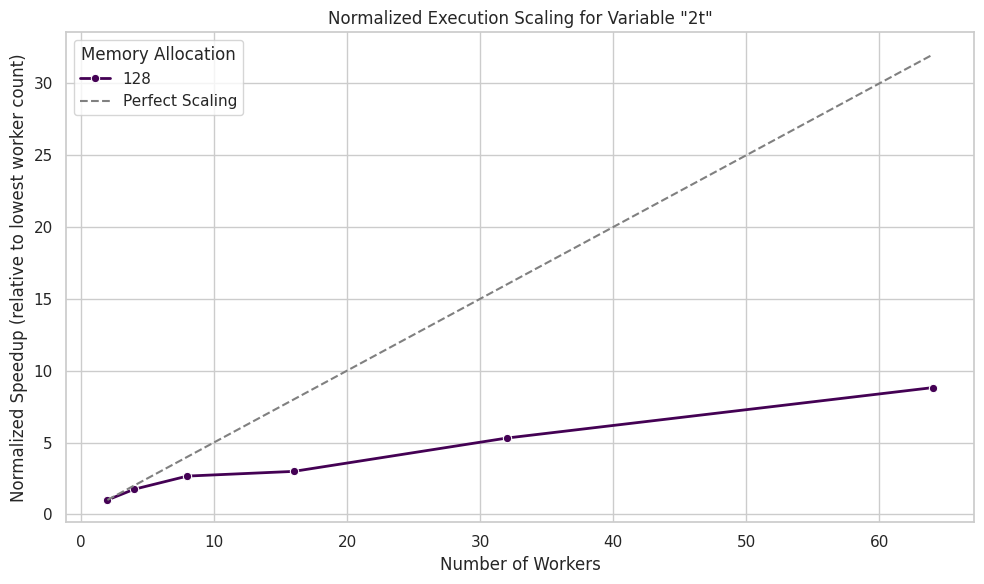

In [11]:
plot_normalized_scaling('./', variable='2t')

   Attempt  Total Time (s)  Retrieve Time (s)  Compute Time (s)  I/O Time (s)  \
0        1           37.51               3.66             16.82         17.02   
1        2           37.12               2.83             16.89         17.40   
2        3           37.08               2.84             17.46         16.78   
3        4           37.24               3.25             17.06         16.92   
4        5           38.00               3.00             17.50         17.50   

  Variable  Workers  Memory (GB)  
0       2t       64          128  
1       2t       64          128  
2       2t       64          128  
3       2t       64          128  
4       2t       64          128  


/tmp/ipykernel_93318/2803047341.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:.3'` for the same effect.

  sns.stripplot(x="Workers", y="Compute Time (s)", hue="Variable", data=df,


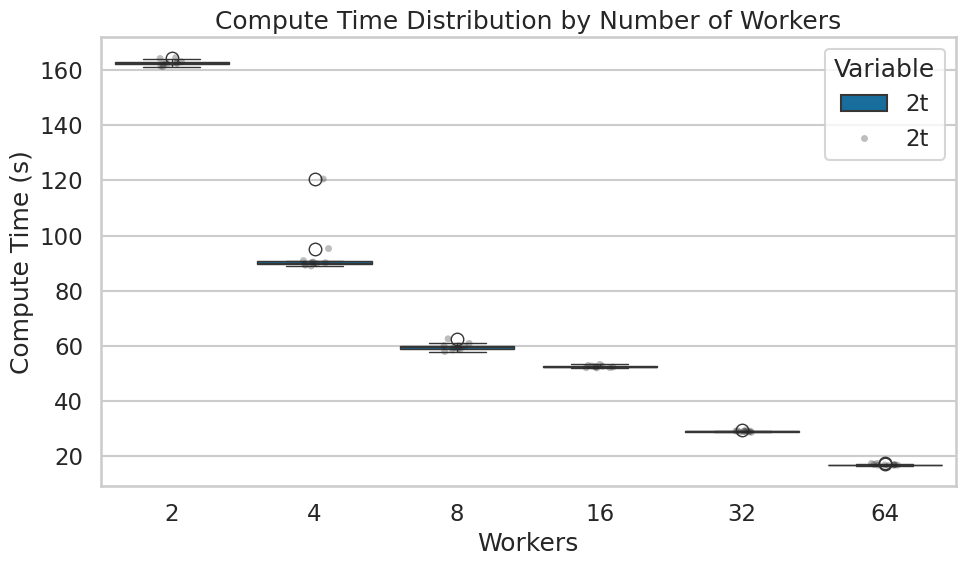

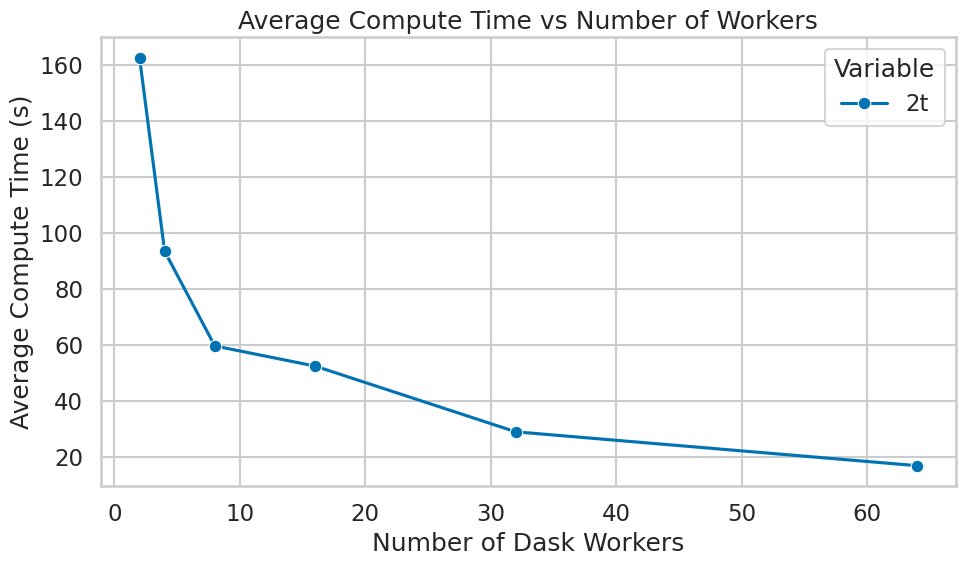

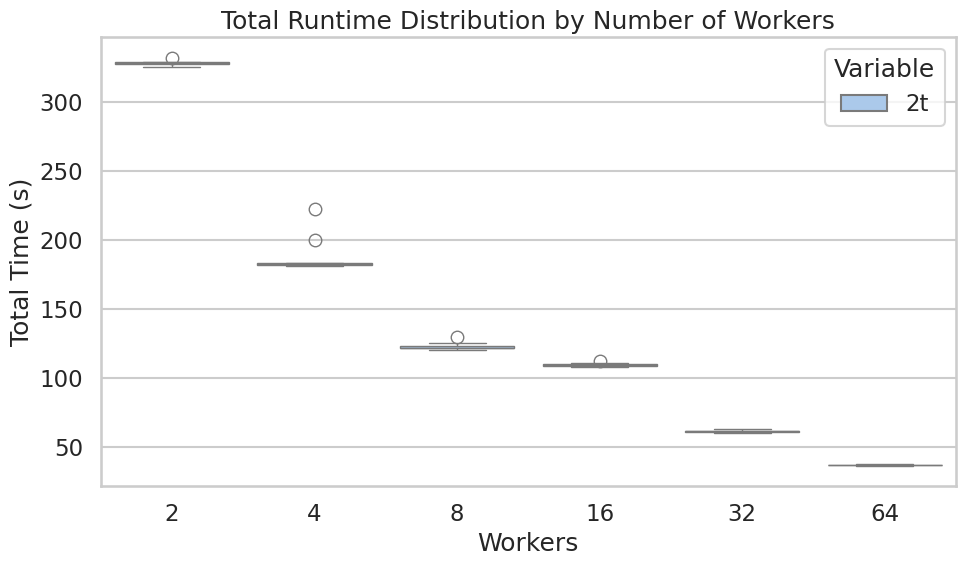

In [4]:
df = load_all_benchmarks("results_*.txt")
print(df.head())

plot_compute_time_box(df)
plot_avg_compute_time(df)
plot_total_time_box(df)